In [9]:
import tensorflow as tf

In [10]:
from tensorflow.keras.layers import Dense, Conv1D, concatenate, Flatten, GRU ,Input

In [11]:
def block(input, stride=2):

  conv1 = Conv1D(filters=32, kernel_size=2, activation='relu',  strides=stride, padding='causal')(input) # padding= causal for preventing data leakage (future access of data )
  conv2 = Conv1D(filters=32, kernel_size=4, activation='relu',  strides=stride, padding='causal')(input)
  conv3 = Conv1D(filters=32, kernel_size=8, activation='relu',  strides=stride, padding='causal')(input)
  print(conv2.shape)
  x  = concatenate([conv1,conv2,conv3], axis=2)
  return x

#  Convolutional layers

In [15]:
def block(input, stride=2):

  conv1 = Conv1D(filters=32, kernel_size=2, activation='relu',  strides=stride, padding='causal')(input) # padding= causal for preventing data leakage (future access of data )
  conv2 = Conv1D(filters=32, kernel_size=4, activation='relu',  strides=stride, padding='causal')(input)
  conv3 = Conv1D(filters=32, kernel_size=8, activation='relu',  strides=stride, padding='causal')(input)
  print(conv2.shape)
  x  = concatenate([conv1,conv2,conv3], axis=2)
  return x

In [16]:
#input = Input(shape=(15000,22))
input = Input(shape=(640,14))
block1 = block(input)
print(block1.shape)
block2=block(block1, stride= 2)
print(block2.shape)
block3=block(block2)
print(block3.shape)

(None, 320, 32)
(None, 320, 96)
(None, 160, 32)
(None, 160, 96)
(None, 80, 32)
(None, 80, 96)


# GRU layers

In [17]:
gru1 = GRU(units=32,return_sequences=True)(block3)
print(gru1.shape)
gru2 = GRU(units=32,return_sequences=True)(gru1)
print(gru2.shape)
gru_con1 = concatenate([gru1,gru2],axis=2)
print(gru_con1.shape)
gru3= GRU(units=32,return_sequences=True)(gru_con1)
print(gru3.shape)
gru_con2 = concatenate([gru1,gru2,gru3],axis=2)
print(gru_con2.shape)
gru_last=GRU(units=32,return_sequences=False)(gru_con2) #(correction) TRUE OR FALSE ??False as we dont need spatial/time dimension info in ANN or dense neural network
print(gru_last.shape)
output=Dense(1,activation='sigmoid')(gru_last)
print(output.shape)

(None, 80, 32)
(None, 80, 32)
(None, 80, 64)
(None, 80, 32)
(None, 80, 96)
(None, 32)
(None, 1)


# compiling the model

In [27]:
from tensorflow.keras.models import Model
model = Model(inputs=input, outputs=output)

model.summary()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 640, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 320, 32)   │        928 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 320, 32)   │      1,824 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 320, 32)   │      3,616 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 320, 96)   │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 160, 32)   │      6,176 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 160, 32)   │     12,320 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 160, 32)   │     24,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 160, 96)   │          0 │ conv1d_3[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 80, 32)    │      6,176 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 80, 32)    │     12,320 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 80, 32)    │     24,608 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 80, 96)    │          0 │ conv1d_6[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 80, 32)    │     12,480 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ (None, 80, 32)    │      6,336 │ gru_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 80, 64)    │          0 │ gru_3[0][0],      │
│ (Concatenate)       │                   │            │ gru_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_5 (GRU)         │ (None, 80, 32)    │      9,408 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 80, 96)    │          0 │ gru_3[0][0],      │
│ (Concatenate)       │                   │            │ gru_4[0][0],      │
│                     │                   │            │ gru_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_6 (GRU)         │ (None, 32)        │     12,480 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         33 │ gru_6[0][0]     

 Total params: 133,313 (520.75 KB)

 Trainable params: 133,313 (520.75 KB)

 Non-trainable params: 0 (0.00 B)

# Whole model function

In [28]:
from tensorflow.keras.layers import Input, Conv1D, GRU, Dense, concatenate
from tensorflow.keras.models import Model


def block(input, stride=2):

    conv1 = Conv1D(
        filters=32,
        kernel_size=2,
        activation='relu',
        strides=stride,
        padding='causal'
    )(input)

    conv2 = Conv1D(
        filters=32,
        kernel_size=4,
        activation='relu',
        strides=stride,
        padding='causal'
    )(input)

    conv3 = Conv1D(
        filters=32,
        kernel_size=8,
        activation='relu',
        strides=stride,
        padding='causal'
    )(input)

    x = concatenate([conv1, conv2, conv3], axis=2)

    return x


def create():

    # Input
    input = Input(shape=(640, 14))

    # CNN blocks
    block1 = block(input)
    block2 = block(block1, stride=2)
    block3 = block(block2)

    # GRU 1
    gru1 = GRU(
        units=32,
        return_sequences=True
    )(block3)

    # GRU 2
    gru2 = GRU(
        units=32,
        return_sequences=True
    )(gru1)

    # Concatenate GRU 1 + GRU 2
    gru_con1 = concatenate(
        [gru1, gru2],
        axis=2
    )

    # GRU 3
    gru3 = GRU(
        units=32,
        return_sequences=True
    )(gru_con1)

    # Concatenate all GRUs
    gru_con2 = concatenate(
        [gru1, gru2, gru3],
        axis=2
    )

    # Final GRU
    gru_last = GRU(
        units=32,
        return_sequences=False
    )(gru_con2)

    # Output
    output = Dense(
        1,
        activation='sigmoid'
    )(gru_last)

    # Create model
    model = Model(
        inputs=input,
        outputs=output
    )

    # Compile
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [29]:
model  = create()
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 640, 14)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_36 (Conv1D)  │ (None, 320, 32)   │        928 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_37 (Conv1D)  │ (None, 320, 32)   │      1,824 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_38 (Conv1D)  │ (None, 320, 32)   │      3,616 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_20      │ (None, 320, 96)   │          0 │ conv1d_36[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_37[0][0],  │
│                     │                   │            │ conv1d_38[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_39 (Conv1D)  │ (None, 160, 32)   │      6,176 │ concatenate_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_40 (Conv1D)  │ (None, 160, 32)   │     12,320 │ concatenate_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_41 (Conv1D)  │ (None, 160, 32)   │     24,608 │ concatenate_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_21      │ (None, 160, 96)   │          0 │ conv1d_39[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_40[0][0],  │
│                     │                   │            │ conv1d_41[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_42 (Conv1D)  │ (None, 80, 32)    │      6,176 │ concatenate_21[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, 80, 32)    │     12,320 │ concatenate_21[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_44 (Conv1D)  │ (None, 80, 32)    │     24,608 │ concatenate_21[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_22      │ (None, 80, 96)    │          0 │ conv1d_42[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_43[0][0],  │
│                     │                   │            │ conv1d_44[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_19 (GRU)        │ (None, 80, 32)    │     12,480 │ concatenate_22[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_20 (GRU)        │ (None, 80, 32)    │      6,336 │ gru_19[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_23      │ (None, 80, 64)    │          0 │ gru_19[0][0],     │
│ (Concatenate)       │                   │            │ gru_20[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_21 (GRU)        │ (None, 80, 32)    │      9,408 │ concatenate_23[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_24      │ (None, 80, 96)    │          0 │ gru_19[0][0],     │
│ (Concatenate)       │                   │            │ gru_20[0][0],     │
│                     │                   │            │ gru_21[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_22 (GRU)        │ (None, 32)        │     12,480 │ concatenate_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ gru_22[0][0]    

 Total params: 133,313 (520.75 KB)

 Trainable params: 133,313 (520.75 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
print(model.count_params())

133313


# Data prep + Training

In [47]:

def plot_loss_curves(history):

  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(0,15)

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
import os

In [33]:
eeg_path=[]
meta_path=[]
for root, dir , files in os.walk('.'):

   for file in files:
    if file.endswith(('.csv', '.zip')):

      if 'nig' in file.lower() :
         eeg_path.append (os.path.join(root,file))
      if 'meta' in file.lower():
         meta_path.append ( os.path.join(root,file))






In [34]:
eeg_path

['.\\EEGs_Nigeria.zip', '.\\metadata_nigeria.csv']

In [13]:
meta_path

['.\\metadata_nigeria.csv']

In [14]:
eeg_path

['.\\EEGs_Nigeria.zip', '.\\metadata_nigeria.csv']

In [35]:
import zipfile
with zipfile.ZipFile(eeg_path[0], 'r') as eeg:
    eeg.extractall('data')

In [36]:
def convertDF2MNE(sub):
    info = mne.create_info(list(sub.columns), ch_types=['eeg'] * len(sub.columns), sfreq=128)
    info.set_montage('standard_1020')
    data=mne.io.RawArray(sub.T, info)
    data.set_eeg_reference()
    data.filter(l_freq=1,h_freq=30)
    epochs=mne.make_fixed_length_epochs(data,duration=5,overlap=1)
    epochs=epochs.drop_bad()
    return epochs.get_data()

In [37]:
def convertDF2MNE(sub):
    info = mne.create_info(
        list(sub.columns),
        ch_types=['eeg'] * len(sub.columns),
        sfreq=128
    )

    eeg_data = sub.to_numpy(dtype=float).T.copy()

    data = mne.io.RawArray(eeg_data, info)

    data.set_eeg_reference()
    data.filter(l_freq=1, h_freq=30)

    epochs = mne.make_fixed_length_epochs(
        data,
        duration=5,
        overlap=1
    )

    epochs = epochs.drop_bad()

    return epochs


In [38]:
meta_df = pd.read_csv(meta_path[0])

In [39]:
EP_sub = meta_df['subject.id'][meta_df['Group']=='epilepsy']
CT_sub = meta_df['subject.id'][meta_df['Group']=='control']
def appender(items,limit):
  iter = 0
  item = []
  for i in items:
    if (iter==limit):
      break
    try:
      reader = pd.read_csv('data/EEGs_Nigeria/signal-{}-1.csv.gz'.format(i), compression='gzip')
      item.append(reader)
      iter=iter+1
    except:
      try:
        reader = pd.read_csv('data/EEGs_Nigeria/signal-{}-2.csv.gz'.format(i), compression='gzip')
        item.append(reader)
        iter=iter+1
      except:
        pass
  return item
Epilepsy = appender(EP_sub,51)
Control = appender(CT_sub,46)
Epilepsy2 = [i.iloc[:,1:15] for i in  Epilepsy]
Control2 = [i.iloc[:,1:15] for i in  Control]
idd_subject =[convertDF2MNE(i) for i in  Epilepsy2]
tdc_subject = [convertDF2MNE(i) for i in  Control2]

Creating RawArray with float64 data, n_channels=14, n_times=34304
    Range : 0 ... 34303 =      0.000 ...   267.992 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 423 samples (3.305 s)

Not setting metadata
66 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 66 events and 640 original time points ...
0 bad epochs drop

In [40]:
control_epochs_labels=[len(i)*[0] for i in tdc_subject]
patients_epochs_labels=[len(i)*[1] for i in idd_subject]

data_list=tdc_subject+idd_subject
label_list=control_epochs_labels+patients_epochs_labels
groups_list=[[i]*len(j) for i, j in enumerate(data_list)]

# labeling data
data_array=np.concatenate(data_list)
label_array=np.concatenate(label_list)
group_array=np.concatenate(groups_list)
data_array=np.moveaxis(data_array,1,2)

print(data_array.shape,label_array.shape,group_array.shape)

(6127, 640, 14) (6127,) (6127,)


In [41]:
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
gkf=GroupKFold(n_splits=5)

In [42]:
for train_index, val_index in gkf.split(data_array, label_array, groups=group_array):
    train_features,train_labels=data_array[train_index],label_array[train_index]
    val_features,val_labels=data_array[val_index],label_array[val_index]
    scaler=StandardScaler()
    train_features = scaler.fit_transform(train_features.reshape(-1, train_features.shape[-1])).reshape(train_features.shape)
    val_features = scaler.transform(val_features.reshape(-1, val_features.shape[-1])).reshape(val_features.shape)

In [43]:
gkf = GroupKFold(n_splits=5)

histories = []

for fold, (train_index, val_index) in enumerate(
    gkf.split(data_array, label_array, groups=group_array),
    start=1
):

    print(f"\n========== Fold {fold} ==========")

    train_features = data_array[train_index]
    train_labels = label_array[train_index]

    val_features = data_array[val_index]
    val_labels = label_array[val_index]

    # Scaling
    scaler = StandardScaler()

    train_features = scaler.fit_transform(
        train_features.reshape(-1, train_features.shape[-1])
    ).reshape(train_features.shape)

    val_features = scaler.transform(
        val_features.reshape(-1, val_features.shape[-1])
    ).reshape(val_features.shape)

    # ⭐ NEW model for this fold
    model = create()

    print(f"Fold number {fold}")

    history = model.fit(
        train_features,
        train_labels,
        epochs=15,
        validation_data=(val_features, val_labels)
    )

    histories.append(history)




========== Fold 1 ==========
Fold number 1
Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.6026 - loss: 0.6645 - val_accuracy: 0.6898 - val_loss: 0.5940
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.7952 - loss: 0.4499 - val_accuracy: 0.7298 - val_loss: 0.5969
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8360 - loss: 0.3799 - val_accuracy: 0.8016 - val_loss: 0.4260
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.8725 - loss: 0.2976 - val_accuracy: 0.8261 - val_loss: 0.3729
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9013 - loss: 0.2370 - val_accuracy: 0.8302 - val_loss: 0.4175
Epoch 6/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.9182 - loss: 0.2089 - val_accuracy: 0.8057 - val_loss: 0.4632
Epoch 7/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.9349 - loss: 0.1651 - val_accuracy: 0.8686 - val_loss: 0.3222
Epoch 8/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/ste

In [44]:
histories

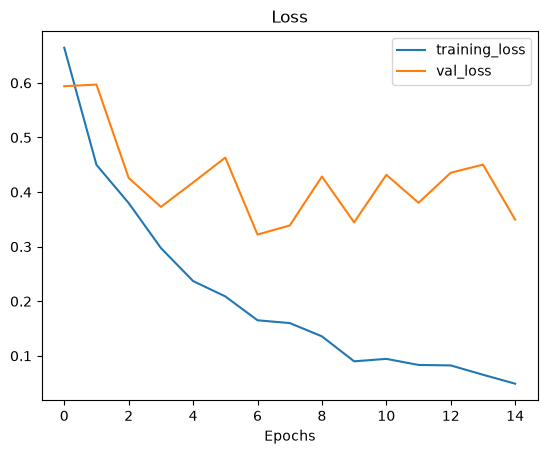

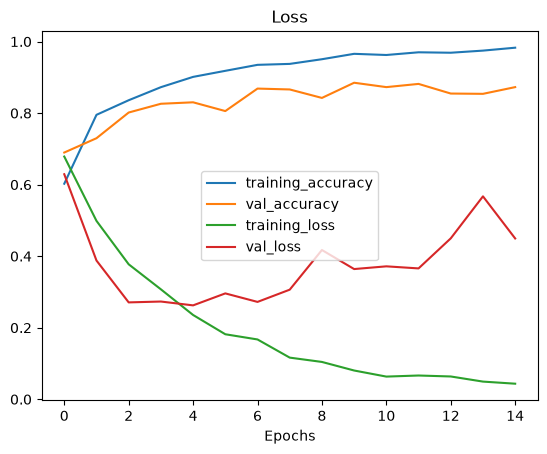

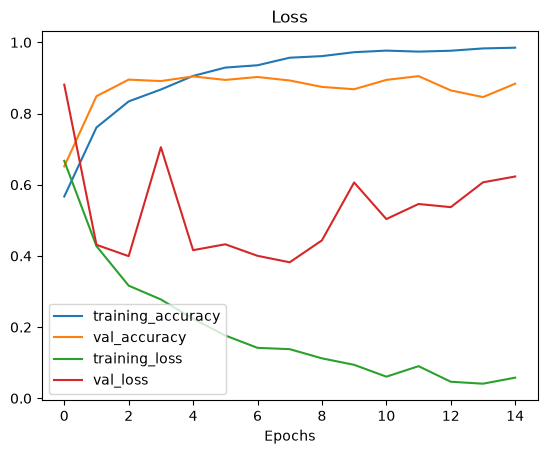

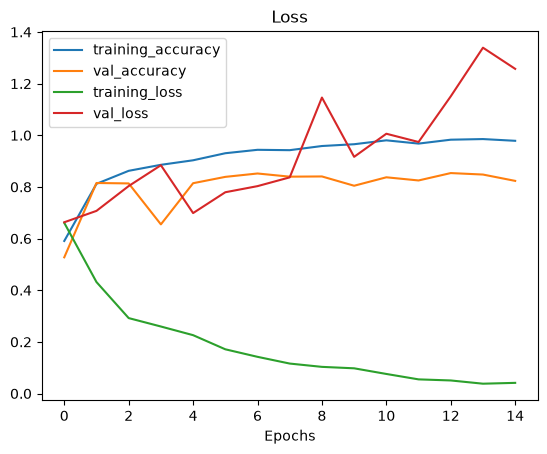

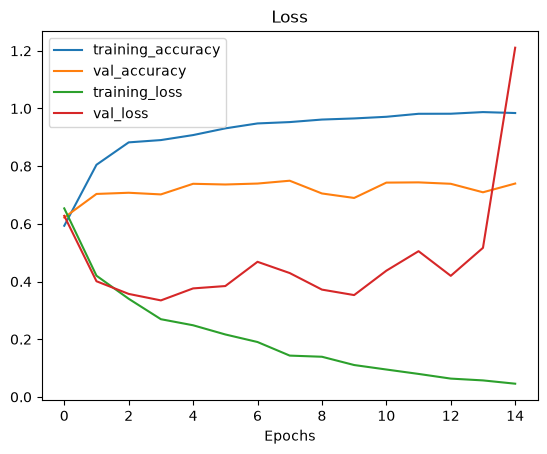

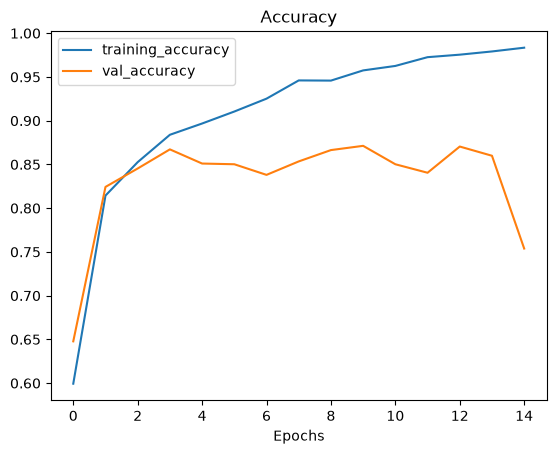

In [49]:
for h in histories:
 plot_loss_curves(h)

In [50]:
import numpy as np

# Training loss
mean_loss = np.mean(
    [history.history['loss'] for history in histories],
    axis=0
)

# Validation loss
mean_val_loss = np.mean(
    [history.history['val_loss'] for history in histories],
    axis=0
)

# Training accuracy
mean_accuracy = np.mean(
    [history.history['accuracy'] for history in histories],
    axis=0
)

# Validation accuracy
mean_val_accuracy = np.mean(
    [history.history['val_accuracy'] for history in histories],
    axis=0
)


In [51]:
val_acc = np.array([
    h.history['val_accuracy'][-1]
    for h in histories
])

val_loss = np.array([
    h.history['val_loss'][-1]
    for h in histories
])

print(
    f"Validation Accuracy: "
    f"{val_acc.mean():.4f} ± {val_acc.std():.4f}"
)

print(
    f"Validation Loss: "
    f"{val_loss.mean():.4f} ± {val_loss.std():.4f}"
)


Validation Accuracy: 0.8147 ± 0.0592
Validation Loss: 0.7780 ± 0.3827


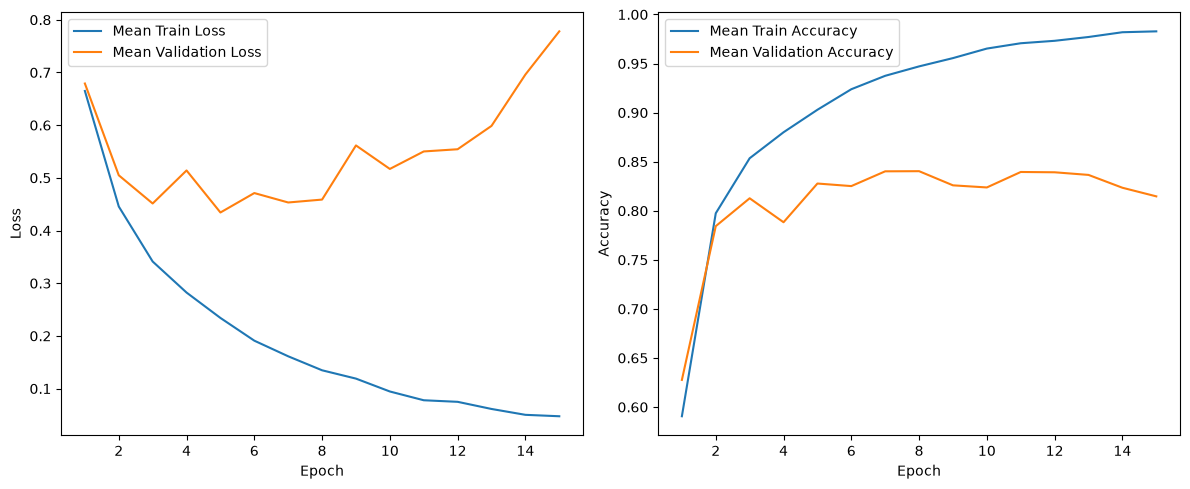

In [52]:
import matplotlib.pyplot as plt

epochs = range(1, len(mean_loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, mean_loss, label='Mean Train Loss')
plt.plot(epochs, mean_val_loss, label='Mean Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, mean_accuracy, label='Mean Train Accuracy')
plt.plot(epochs, mean_val_accuracy, label='Mean Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


# Power Band Feature


In [64]:
# source: https://mne.tools/stable/auto_tutorials/clinical/60_sleep.html#sphx-glr-auto-tutorials-clinical-60-sleep-py
from mne.time_frequency import psd_welch
def eeg_power_band(epochs):
    """EEG relative power band feature extraction.

    This function takes an ``mne.Epochs`` object and creates EEG features basedg
    on relative power in specific frequency bands that are compatible with
    scikit-learn.

    Parameters
    ----------
    epochs : Epochs
        The data.

    Returns
    -------
    X : numpy array of shape [n_samples, 5]
        Transformed data.
    """
    # specific frequency bands
    FREQ_BANDS = {"delta": [0.5, 4],
                  "theta": [4, 8],
                  "alpha": [8, 16],
                  # "sigma": [11.5, 15.5],
                  "beta": [16, 32],
                  # "gamma": [30, 45],
                  }

    psds, freqs = psd_welch(epochs, picks='eeg', fmin=1, fmax=30)# Compute the PSD using the Welch method
    psds /= np.sum(psds, axis=-1, keepdims=True)    # Normalize the PSDs

    X = []#For each frequency band, compute the mean PSD in that band
    for fmin, fmax in FREQ_BANDS.values():
        psds_band = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)# Compute the mean PSD in each frequency band.
        X.append(psds_band)

    return np.concatenate(X, axis=1)#Concatenate the mean PSDs for each band into a single feature vector

ImportError: cannot import name 'psd_welch' from 'mne.time_frequency' (f:\WORK\Thesis\OT_TEHSIS\.venv\Lib\site-packages\mne\time_frequency\__init__.py)

In [ ]:
import numpy as np
import mne


def eeg_power_band(epochs):
    """
    Extract relative EEG power in delta, theta, alpha, and beta bands.

    Parameters
    ----------
    epochs : mne.Epochs
        Epoched EEG data.

    Returns
    -------
    X : numpy.ndarray
        Shape: (n_epochs, n_channels * 4)
        Relative power features for delta, theta, alpha, and beta.
    """

    # Frequency bands
    FREQ_BANDS = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 16),
        "beta": (16, 30),
    }

    # --------------------------------------------------
    # 1. Calculate PSD using Welch method
    # --------------------------------------------------

    spectrum = epochs.compute_psd(
        method="welch",
        fmin=0.5,
        fmax=30,
        picks="eeg"
    )

    # Get PSD values and frequencies
    psds, freqs = spectrum.get_data(return_freqs=True)

    print("PSD shape:", psds.shape)
    print("Frequency shape:", freqs.shape)

    # --------------------------------------------------
    # 2. Convert PSD to relative power
    # --------------------------------------------------

    psds /= np.sum(psds, axis=-1, keepdims=True)

    # --------------------------------------------------
    # 3. Extract power from each frequency band
    # --------------------------------------------------

    X = []

    for band, (fmin, fmax) in FREQ_BANDS.items():

        # Select frequencies belonging to this band
        freq_mask = (freqs >= fmin) & (freqs < fmax)

        # Mean power within the frequency band
        psds_band = psds[:, :, freq_mask].mean(axis=-1)

        print(
            band,
            "shape:",
            psds_band.shape
        )

        X.append(psds_band)

    # --------------------------------------------------
    # 4. Concatenate all frequency bands
    # --------------------------------------------------

    X = np.concatenate(X, axis=1)

    print("Final feature shape:", X.shape)

    return X


In [59]:
Epilepsy2 = [i.iloc[:, 1:15] for i in Epilepsy]
Control2 = [i.iloc[:, 1:15] for i in Control]
Epilepsy3 =[convertDF2MNE(i) for i in  Epilepsy2]
Control3 = [convertDF2MNE(i) for i in  Control2]
Epilepsy_epochs = mne.concatenate_epochs(Epilepsy3)
Control_epochs = mne.concatenate_epochs(Control3)

Creating RawArray with float64 data, n_channels=14, n_times=34304
    Range : 0 ... 34303 =      0.000 ...   267.992 secs
Ready.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 423 samples (3.305 s)

Not setting metadata
66 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 66 events and 640 original time points ...
0 bad epochs drop

In [61]:
Epilepsy_group = np.concatenate([
    [i] * len(Epilepsy3[i])
    for i in range(len(Epilepsy3))
])

Control_group = np.concatenate([
    [i + len(Epilepsy3)] * len(Control3[i])
    for i in range(len(Control3))
])




Epilepsy_label=np.concatenate([[0]*len(Epilepsy3[i]) for i in range(len(Epilepsy3))])  
Control_label=np.concatenate([[1]*len(Control3[i]) for i in range(len(Control3))])

In [62]:
data=mne.concatenate_epochs([Epilepsy_epochs,Control_epochs])
group=np.concatenate((Epilepsy_group,Control_group))
label=np.concatenate((Epilepsy_label,Control_label))
print(len(data),len(group),len(label))

Not setting metadata
6127 matching events found
No baseline correction applied
6127 6127 6127


In [101]:
features = eeg_power_band(data)

print(features.shape)

Effective window size : 5.000 (s)
PSD shape: (6127, 14, 148)
Frequency shape: (148,)
delta shape: (6127, 14)
theta shape: (6127, 14)
alpha shape: (6127, 14)
beta shape: (6127, 14)
Final feature shape: (6127, 56)
(6127, 56)


In [109]:
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model

def create_psd_model():

    inputs = Input(shape=(56,))

    x = Dense(128, activation='relu')(inputs)
    x = Dropout(0.2)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)

    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model



In [103]:
# Extract PSD features
X = eeg_power_band(data)

print("X shape:", X.shape)
print("Labels shape:", label_array.shape)
print("Groups shape:", group_array.shape)


Effective window size : 5.000 (s)
PSD shape: (6127, 14, 148)
Frequency shape: (148,)
delta shape: (6127, 14)
theta shape: (6127, 14)
alpha shape: (6127, 14)
beta shape: (6127, 14)
Final feature shape: (6127, 56)
X shape: (6127, 56)
Labels shape: (6127,)
Groups shape: (6127,)


In [100]:
model = create_psd_model()
model.summary()

Model: "functional_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_42 (InputLayer)     │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 128)            │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,665 (69.00 KB)

 Non-trainable params: 0 (0.00 B)

In [110]:
gkf = GroupKFold(n_splits=5)

histories = []

for fold, (train_index, val_index) in enumerate(
    gkf.split(X, label_array, groups=group_array),
    start=1
):

    print(f"\n========== Fold {fold} ==========")

    X_train = X[train_index]
    y_train = label_array[train_index]

    X_val = X[val_index]
    y_val = label_array[val_index]

    # Scale ONLY training data
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

   
    model = create_psd_model()

    history = model.fit(
        X_train,
        y_train,
        epochs=70,
        validation_data=(X_val, y_val),
        verbose=1
    )

    histories.append(history)



========== Fold 1 ==========
Epoch 1/70
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6695 - loss: 0.6032 - val_accuracy: 0.7886 - val_loss: 0.4795
Epoch 2/70
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7315 - loss: 0.5311 - val_accuracy: 0.8065 - val_loss: 0.4428
Epoch 3/70
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7495 - loss: 0.5037 - val_accuracy: 0.7976 - val_loss: 0.4561
Epoch 4/70
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7627 - loss: 0.4985 - val_accuracy: 0.8163 - val_loss: 0.4377
Epoch 5/70
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7699 - loss: 0.4786 - val_accuracy: 0.8122 - val_loss: 0.4483
Epoch 6/70
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7768 - loss: 0.4722 - val_accuracy: 0.8253 - val_loss: 0.4246
Epoch 7/70
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7793 - loss: 0.4618 - val_accuracy: 0.8131 - val_loss: 0.4431
Epoch 8/70
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7899 - l

In [112]:
for fold, history in enumerate(histories, start=1):

    print(
        f"Fold {fold}: "
        f"Train Acc = {history.history['accuracy'][-1]:.4f}, "
        f"Val Acc = {history.history['val_accuracy'][-1]:.4f}, "
        f"Train Loss = {history.history['loss'][-1]:.4f}, "
        f"Val Loss = {history.history['val_loss'][-1]:.4f}"
    )


Fold 1: Train Acc = 0.9027, Val Acc = 0.7878, Train Loss = 0.2253, Val Loss = 0.6405
Fold 2: Train Acc = 0.9107, Val Acc = 0.7635, Train Loss = 0.2125, Val Loss = 0.7106
Fold 3: Train Acc = 0.9076, Val Acc = 0.7441, Train Loss = 0.2118, Val Loss = 0.7264
Fold 4: Train Acc = 0.9058, Val Acc = 0.7267, Train Loss = 0.2171, Val Loss = 0.7820
Fold 5: Train Acc = 0.9117, Val Acc = 0.7271, Train Loss = 0.2072, Val Loss = 0.7290


In [113]:
import numpy as np

# Training loss
mean_loss = np.mean(
    [history.history['loss'] for history in histories],
    axis=0
)

# Validation loss
mean_val_loss = np.mean(
    [history.history['val_loss'] for history in histories],
    axis=0
)

# Training accuracy
mean_accuracy = np.mean(
    [history.history['accuracy'] for history in histories],
    axis=0
)

# Validation accuracy
mean_val_accuracy = np.mean(
    [history.history['val_accuracy'] for history in histories],
    axis=0
)


val_acc = np.array([
    h.history['val_accuracy'][-1]
    for h in histories
])

val_loss = np.array([
    h.history['val_loss'][-1]
    for h in histories
])

print(
    f"Validation Accuracy: "
    f"{val_acc.mean():.4f} ± {val_acc.std():.4f}"
)

print(
    f"Validation Loss: "
    f"{val_loss.mean():.4f} ± {val_loss.std():.4f}"
)


Validation Accuracy: 0.7498 ± 0.0233
Validation Loss: 0.7177 ± 0.0455


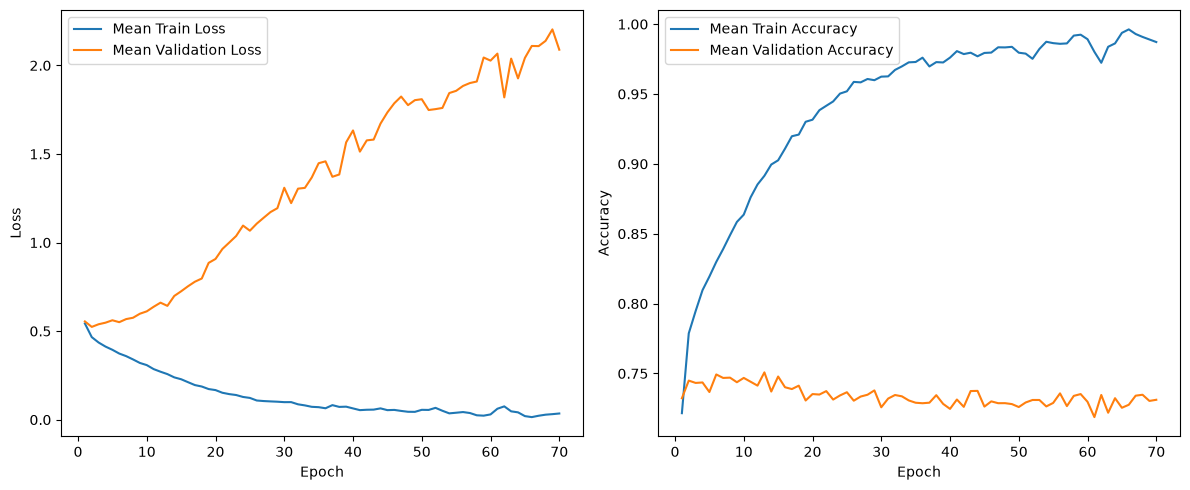

In [ ]:
## No dropout 
import matplotlib.pyplot as plt

epochs = range(1, len(mean_loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, mean_loss, label='Mean Train Loss')
plt.plot(epochs, mean_val_loss, label='Mean Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, mean_accuracy, label='Mean Train Accuracy')
plt.plot(epochs, mean_val_accuracy, label='Mean Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

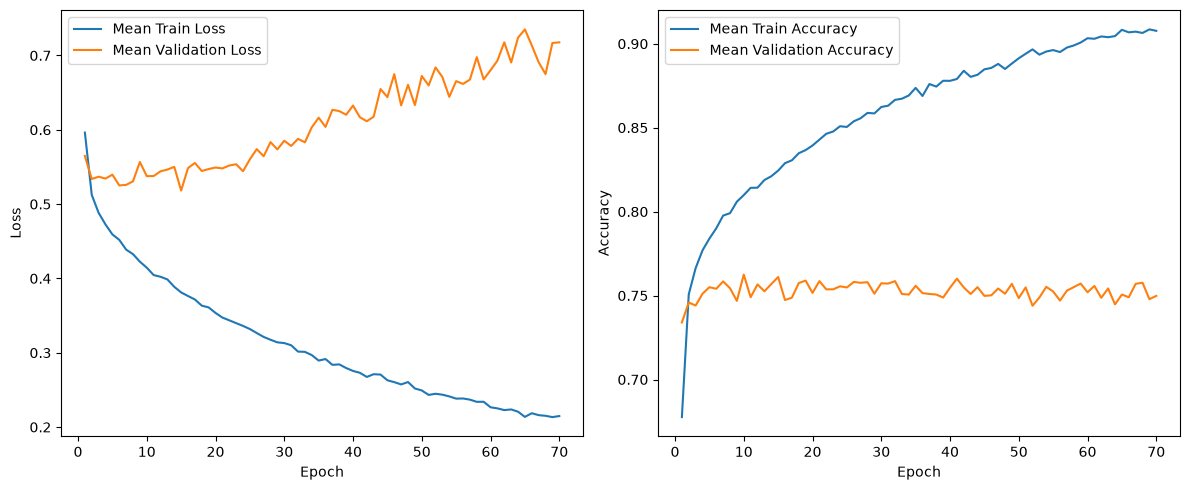

In [114]:
# with dropout 
import matplotlib.pyplot as plt

epochs = range(1, len(mean_loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, mean_loss, label='Mean Train Loss')
plt.plot(epochs, mean_val_loss, label='Mean Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, mean_accuracy, label='Mean Train Accuracy')
plt.plot(epochs, mean_val_accuracy, label='Mean Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# power band model(conv1d gru)

In [94]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    GRU,
    Dense,
    Dropout,
    BatchNormalization,
    concatenate
)

from tensorflow.keras.models import Model


def create_psd_chrononet():

    inputs = Input(shape=(4, 14))

    # =========================================
    # Convolutional block
    # =========================================

    conv1 = Conv1D(
        filters=32,
        kernel_size=2,
        padding='same',
        activation='relu'
    )(inputs)

    conv2 = Conv1D(
        filters=32,
        kernel_size=3,
        padding='same',
        activation='relu'
    )(inputs)

    conv3 = Conv1D(
        filters=32,
        kernel_size=4,
        padding='same',
        activation='relu'
    )(inputs)

    x = concatenate([conv1, conv2, conv3], axis=-1)

    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # =========================================
    # GRU
    # =========================================

    gru1 = GRU(
        32,
        return_sequences=True
    )(x)

    gru2 = GRU(
        32,
        return_sequences=True
    )(gru1)

    # Skip connection
    gru_concat = concatenate(
        [gru1, gru2],
        axis=-1
    )

    gru3 = GRU(
        32,
        return_sequences=True
    )(gru_concat)

    # =========================================
    # Final GRU
    # =========================================

    gru_final = GRU(
        32,
        return_sequences=False
    )(gru3)

    # =========================================
    # Dense classifier
    # =========================================

    x = Dense(
        32,
        activation='relu'
    )(gru_final)

    x = Dropout(0.3)(x)

    outputs = Dense(
        1,
        activation='sigmoid'
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [95]:
model.summary()

Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_35      │ (None, 4, 14)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_120 (Conv1D) │ (None, 4, 32)     │        928 │ input_layer_35[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_121 (Conv1D) │ (None, 4, 32)     │      1,376 │ input_layer_35[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_122 (Conv1D) │ (None, 4, 32)     │      1,824 │ input_layer_35[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_70      │ (None, 4, 96)     │          0 │ conv1d_120[0][0], │
│ (Concatenate)       │                   │            │ conv1d_121[0][0], │
│                     │                   │            │ conv1d_122[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 96)     │        384 │ concatenate_70[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_50          │ (None, 4, 96)     │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_83 (GRU)        │ (None, 4, 32)     │     12,480 │ dropout_50[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_84 (GRU)        │ (None, 4, 32)     │      6,336 │ gru_83[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_71      │ (None, 4, 64)     │          0 │ gru_83[0][0],     │
│ (Concatenate)       │                   │            │ gru_84[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_85 (GRU)        │ (None, 4, 32)     │      9,408 │ concatenate_71[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_86 (GRU)        │ (None, 32)        │      6,336 │ gru_85[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_90 (Dense)    │ (None, 32)        │      1,056 │ gru_86[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_51          │ (None, 32)        │          0 │ dense_90[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_91 (Dense)    │ (None, 1)         │         33 │ dropout_51[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 120,101 (469.15 KB)

 Trainable params: 39,969 (156.13 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 79,940 (312.27 KB)

In [97]:
X = eeg_power_band(data)

print(X.shape)
X = X.reshape(X.shape[0], 4, 14)

print(X.shape)


Effective window size : 5.000 (s)
PSD shape: (6127, 14, 148)
Frequency shape: (148,)
delta shape: (6127, 14)
theta shape: (6127, 14)
alpha shape: (6127, 14)
beta shape: (6127, 14)
Final feature shape: (6127, 56)
(6127, 56)
(6127, 4, 14)


In [98]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
import numpy as np

gkf = GroupKFold(n_splits=5)

histories = []

for fold, (train_index, val_index) in enumerate(
    gkf.split(
        X,
        label_array,
        groups=group_array
    ),
    start=1
):

    print(f"\n========================")
    print(f"Fold {fold}")
    print(f"========================")

    # --------------------------------
    # Split
    # --------------------------------

    X_train = X[train_index]
    X_val = X[val_index]

    y_train = label_array[train_index]
    y_val = label_array[val_index]

    print("Before scaling:")
    print("Train:", X_train.shape)
    print("Val:", X_val.shape)

    # --------------------------------
    # StandardScaler
    # --------------------------------

    scaler = StandardScaler()

    # Flatten samples and time/frequency dimension
    X_train_2d = X_train.reshape(
        -1,
        X_train.shape[-1]
    )

    X_val_2d = X_val.reshape(
        -1,
        X_val.shape[-1]
    )

    X_train_2d = scaler.fit_transform(
        X_train_2d
    )

    X_val_2d = scaler.transform(
        X_val_2d
    )

    # Back to 3D
    X_train = X_train_2d.reshape(
        X_train.shape
    )

    X_val = X_val_2d.reshape(
        X_val.shape
    )

    # --------------------------------
    # NEW model for every fold
    # --------------------------------

    model = create_psd_chrononet()

    

    # --------------------------------
    # Train
    # --------------------------------

    history = model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=32,
        validation_data=(
            X_val,
            y_val
        ),
        verbose=1
    )
    model.summary()

    histories.append(history)



Fold 1
Before scaling:
Train: (4902, 4, 14)
Val: (1225, 4, 14)
Epoch 1/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6516 - loss: 0.6253 - val_accuracy: 0.7763 - val_loss: 0.5458
Epoch 2/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6995 - loss: 0.5724 - val_accuracy: 0.7469 - val_loss: 0.5043
Epoch 3/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7250 - loss: 0.5464 - val_accuracy: 0.7951 - val_loss: 0.4726
Epoch 4/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7211 - loss: 0.5413 - val_accuracy: 0.7910 - val_loss: 0.4483
Epoch 5/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7242 - loss: 0.5360 - val_accuracy: 0.7755 - val_loss: 0.5030


Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_37      │ (None, 4, 14)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_126 (Conv1D) │ (None, 4, 32)     │        928 │ input_layer_37[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_127 (Conv1D) │ (None, 4, 32)     │      1,376 │ input_layer_37[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_128 (Conv1D) │ (None, 4, 32)     │      1,824 │ input_layer_37[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_74      │ (None, 4, 96)     │          0 │ conv1d_126[0][0], │
│ (Concatenate)       │                   │            │ conv1d_127[0][0], │
│                     │                   │            │ conv1d_128[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 96)     │        384 │ concatenate_74[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_54          │ (None, 4, 96)     │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_91 (GRU)        │ (None, 4, 32)     │     12,480 │ dropout_54[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_92 (GRU)        │ (None, 4, 32)     │      6,336 │ gru_91[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_75      │ (None, 4, 64)     │          0 │ gru_91[0][0],     │
│ (Concatenate)       │                   │            │ gru_92[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_93 (GRU)        │ (None, 4, 32)     │      9,408 │ concatenate_75[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_94 (GRU)        │ (None, 32)        │      6,336 │ gru_93[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_94 (Dense)    │ (None, 32)        │      1,056 │ gru_94[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_55          │ (None, 32)        │          0 │ dense_94[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_95 (Dense)    │ (None, 1)         │         33 │ dropout_55[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 120,101 (469.15 KB)

 Trainable params: 39,969 (156.13 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_41      │ (None, 4, 14)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_138 (Conv1D) │ (None, 4, 32)     │        928 │ input_layer_41[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_139 (Conv1D) │ (None, 4, 32)     │      1,376 │ input_layer_41[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_140 (Conv1D) │ (None, 4, 32)     │      1,824 │ input_layer_41[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_82      │ (None, 4, 96)     │          0 │ conv1d_138[0][0], │
│ (Concatenate)       │                   │            │ conv1d_139[0][0], │
│                     │                   │            │ conv1d_140[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 96)     │        384 │ concatenate_82[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_62          │ (None, 4, 96)     │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_107 (GRU)       │ (None, 4, 32)     │     12,480 │ dropout_62[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_108 (GRU)       │ (None, 4, 32)     │      6,336 │ gru_107[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_83      │ (None, 4, 64)     │          0 │ gru_107[0][0],    │
│ (Concatenate)       │                   │            │ gru_108[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_109 (GRU)       │ (None, 4, 32)     │      9,408 │ concatenate_83[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_110 (GRU)       │ (None, 32)        │      6,336 │ gru_109[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_102 (Dense)   │ (None, 32)        │      1,056 │ gru_110[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_63          │ (None, 32)        │          0 │ dense_102[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_103 (Dense)   │ (None, 1)         │         33 │ dropout_63[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 120,101 (469.15 KB)

 Trainable params: 39,969 (156.13 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 79,940 (312.27 KB)

In [85]:
for fold, history in enumerate(histories, start=1):

    print(
        f"Fold {fold}: "
        f"Train Acc = {history.history['accuracy'][-1]:.4f}, "
        f"Val Acc = {history.history['val_accuracy'][-1]:.4f}, "
        f"Train Loss = {history.history['loss'][-1]:.4f}, "
        f"Val Loss = {history.history['val_loss'][-1]:.4f}"
    )


Fold 1: Train Acc = 0.7756, Val Acc = 0.8131, Train Loss = 0.4676, Val Loss = 0.4603
Fold 2: Train Acc = 0.7894, Val Acc = 0.7390, Train Loss = 0.4440, Val Loss = 0.5263
Fold 3: Train Acc = 0.8038, Val Acc = 0.7089, Train Loss = 0.4211, Val Loss = 0.5940
Fold 4: Train Acc = 0.7918, Val Acc = 0.7062, Train Loss = 0.4352, Val Loss = 0.6368
Fold 5: Train Acc = 0.7978, Val Acc = 0.7312, Train Loss = 0.4350, Val Loss = 0.5334


In [86]:
import numpy as np

# Training loss
mean_loss = np.mean(
    [history.history['loss'] for history in histories],
    axis=0
)

# Validation loss
mean_val_loss = np.mean(
    [history.history['val_loss'] for history in histories],
    axis=0
)

# Training accuracy
mean_accuracy = np.mean(
    [history.history['accuracy'] for history in histories],
    axis=0
)

# Validation accuracy
mean_val_accuracy = np.mean(
    [history.history['val_accuracy'] for history in histories],
    axis=0
)
print("Mean loss:", mean_loss)
print("Mean validation loss:", mean_val_loss)

print("Mean accuracy:", mean_accuracy)
print("Mean validation accuracy:", mean_val_accuracy)


Mean loss: [0.60420524 0.54647126 0.53419516 0.52278591 0.51833448 0.51164826
 0.5095619  0.49847329 0.49993745 0.4939016  0.49113153 0.48858478
 0.48085501 0.48024559 0.4789701  0.47363307 0.47295705 0.47164083
 0.46903309 0.46536247 0.46371771 0.45643864 0.45802973 0.45202597
 0.44980241 0.44714532 0.44792097 0.44312885 0.44418644 0.4406022 ]
Mean validation loss: [0.59349881 0.54488847 0.54167444 0.53682144 0.54666384 0.53204797
 0.54140123 0.53567093 0.53065609 0.55083121 0.5539708  0.55160529
 0.52709882 0.54383487 0.52175202 0.5333663  0.53829091 0.52650068
 0.54327589 0.55725424 0.55607197 0.60589164 0.54250312 0.56127212
 0.55435113 0.5972204  0.56468089 0.56487191 0.55054057 0.55018101]
Mean accuracy: [0.6680638  0.72739186 0.73490133 0.74057597 0.74134777 0.74693866
 0.75003719 0.75726455 0.75559052 0.76003729 0.7606901  0.75811682
 0.76742222 0.77076566 0.76909502 0.77195257 0.76962497 0.77411608
 0.77117772 0.77644054 0.77476566 0.78084393 0.7822762  0.78598961
 0.7854564  

In [87]:
val_acc = np.array([
    h.history['val_accuracy'][-1]
    for h in histories
])

val_loss = np.array([
    h.history['val_loss'][-1]
    for h in histories
])

print(
    f"\nMean Validation Accuracy: "
    f"{val_acc.mean():.4f} ± {val_acc.std():.4f}"
)

print(
    f"Mean Validation Loss: "
    f"{val_loss.mean():.4f} ± {val_loss.std():.4f}"
)



Mean Validation Accuracy: 0.7397 ± 0.0388
Mean Validation Loss: 0.5502 ± 0.0606


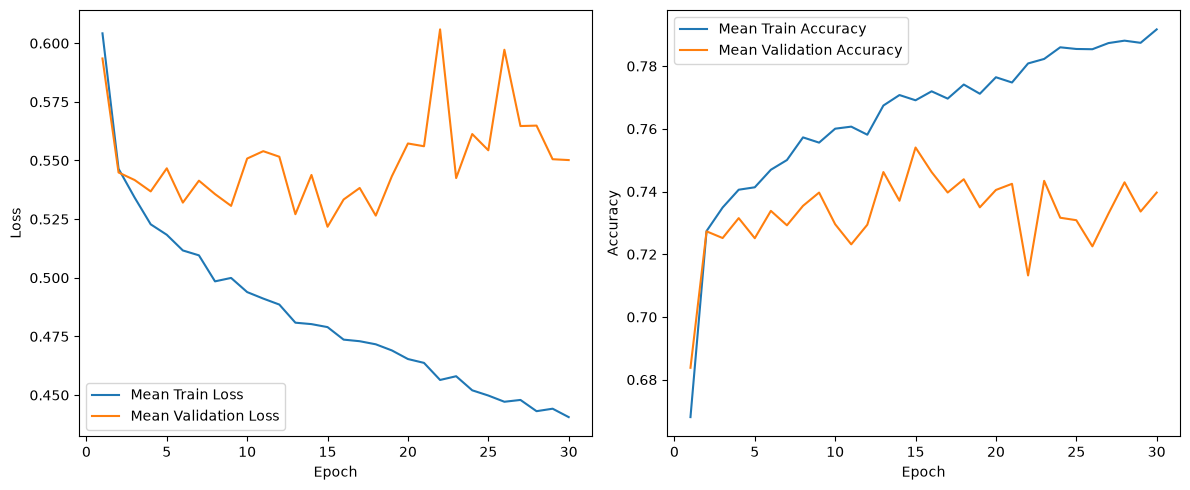

In [88]:
import matplotlib.pyplot as plt

epochs = range(1, len(mean_loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, mean_loss, label='Mean Train Loss')
plt.plot(epochs, mean_val_loss, label='Mean Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, mean_accuracy, label='Mean Train Accuracy')
plt.plot(epochs, mean_val_accuracy, label='Mean Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()